In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,matthews_corrcoef, ConfusionMatrixDisplay


## Loading Dataset

In [2]:
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## Separating Features and Label

In [5]:
X = df.drop('HeartDisease', axis = 1)
y = df['HeartDisease']
print(X.shape, y.shape)

(918, 11) (918,)


## Holdout Cross Validation

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(734, 11) (734,) (184, 11) (184,)


In [7]:
y_train.value_counts()

HeartDisease
1    401
0    333
Name: count, dtype: int64

In [8]:
y_test.value_counts()

HeartDisease
1    107
0     77
Name: count, dtype: int64

In [9]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

## Encoding Categorical Features

In [10]:
# ohe = OneHotEncoder(drop='first',sparse=False,handle_unknown='infrequent_if_exist',dtype = np.int64)
ohe = OneHotEncoder(drop='first',sparse=False,handle_unknown='infrequent_if_exist',dtype = np.int64)
print(X_train.shape,X_test.shape)

X_train_ohe = ohe.fit_transform(X_train[['Sex', 'ChestPainType','RestingECG','ExerciseAngina','ST_Slope']])

X_test_ohe = ohe.transform(X_test[['Sex', 'ChestPainType','RestingECG','ExerciseAngina','ST_Slope']])

print(X_train_ohe.shape,X_test_ohe.shape)


(734, 11) (184, 11)
(734, 9) (184, 9)


C:\Users\JAWAD\anaconda3\envs\python310\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [11]:
X_train_num = X_train.drop(columns=['Sex', 'ChestPainType','RestingECG','ExerciseAngina','ST_Slope']).values.astype('int64')

X_test_num = X_test.drop(columns=['Sex', 'ChestPainType','RestingECG','ExerciseAngina','ST_Slope']).values.astype('int64')

print(X_train_num.shape,X_test_num.shape)

(734, 6) (184, 6)


In [12]:
X_train_transformed = np.concatenate((X_train_num, X_train_ohe),axis=1)
X_test_transformed = np.concatenate((X_test_num, X_test_ohe),axis=1)
print(X_train_transformed.shape, X_test_transformed.shape)

(734, 15) (184, 15)


In [13]:
# from imblearn.combine import SMOTEENN,SMOTETomek

# # ro = SMOTE(sampling_strategy='minority')
# ro = SMOTETomek()

# print(X_train_transformed.shape,y_train.shape)
# X_train_transformed,y_train = ro.fit_resample(X_train_transformed,y_train)
# print(X_train_transformed.shape,y_train.shape)

## Applying Feature Scaling

In [14]:
mms = MinMaxScaler()

X_train_transformed = mms.fit_transform(X_train_transformed)
X_test_transformed = mms.transform(X_test_transformed)

In [15]:
# from sklearn.feature_selection import mutual_info_classif
# # determine the mutual information
# mutual_info = mutual_info_classif(X_train_transformed, y_train)
# mutual_info = pd.DataFrame(mutual_info)
# mutual_info.plot.bar(figsize=(20, 8))


## Defining and Traning ML Model

In [22]:
from sklearn.neighbors import KNeighborsClassifier


clf = KNeighborsClassifier(n_neighbors=3)

clf.fit(X_train_transformed, y_train)

KNeighborsClassifier(n_neighbors=3)

## Getting Predictions on Training and Test Data

In [23]:
ypred = clf.predict(X_train_transformed)
yhat = clf.predict(X_test_transformed)

In [24]:
ypred

array([0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,

In [25]:
yhat

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1], dtype=int64)

## Training Performance Measures

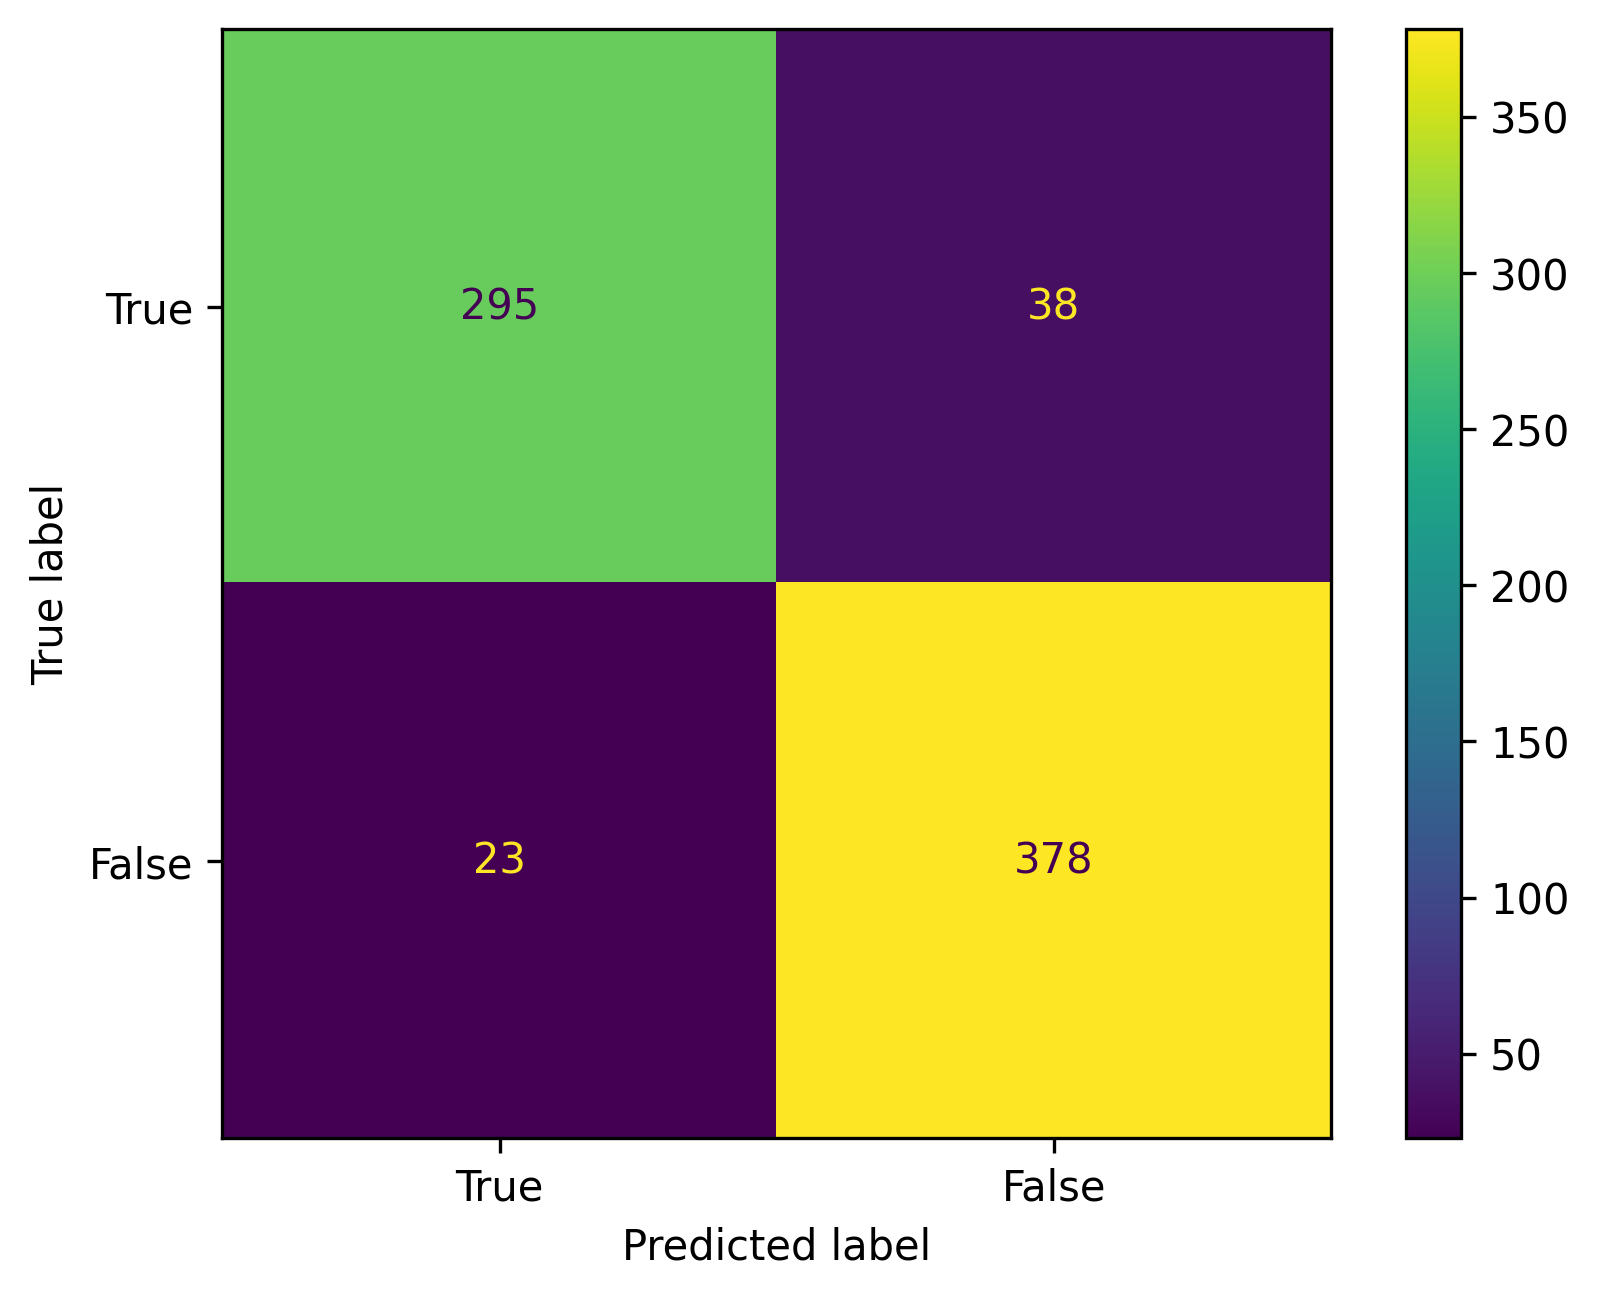

Training Measures:
Accuracy: 0.916894
Precision: 0.908654
Recall: 0.942643
F1_Score: 0.925337
Matthews correlation coefficient: 0.832419


In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

accu = accuracy_score(y_train,ypred)
prec = precision_score(y_train,ypred)
rec = recall_score(y_train,ypred)
fs = f1_score(y_train,ypred)
cm = confusion_matrix(y_train,ypred)
mcc = matthews_corrcoef(y_train,ypred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [True, False])
cm_display.plot()
plt.show()

print('Training Measures:')
print('Accuracy: %f' % accu)
print('Precision: %f' % prec)
print('Recall: %f' % rec)
print('F1_Score: %f' % fs)
print('Matthews correlation coefficient: %f' % mcc)

## Test Performance Measures

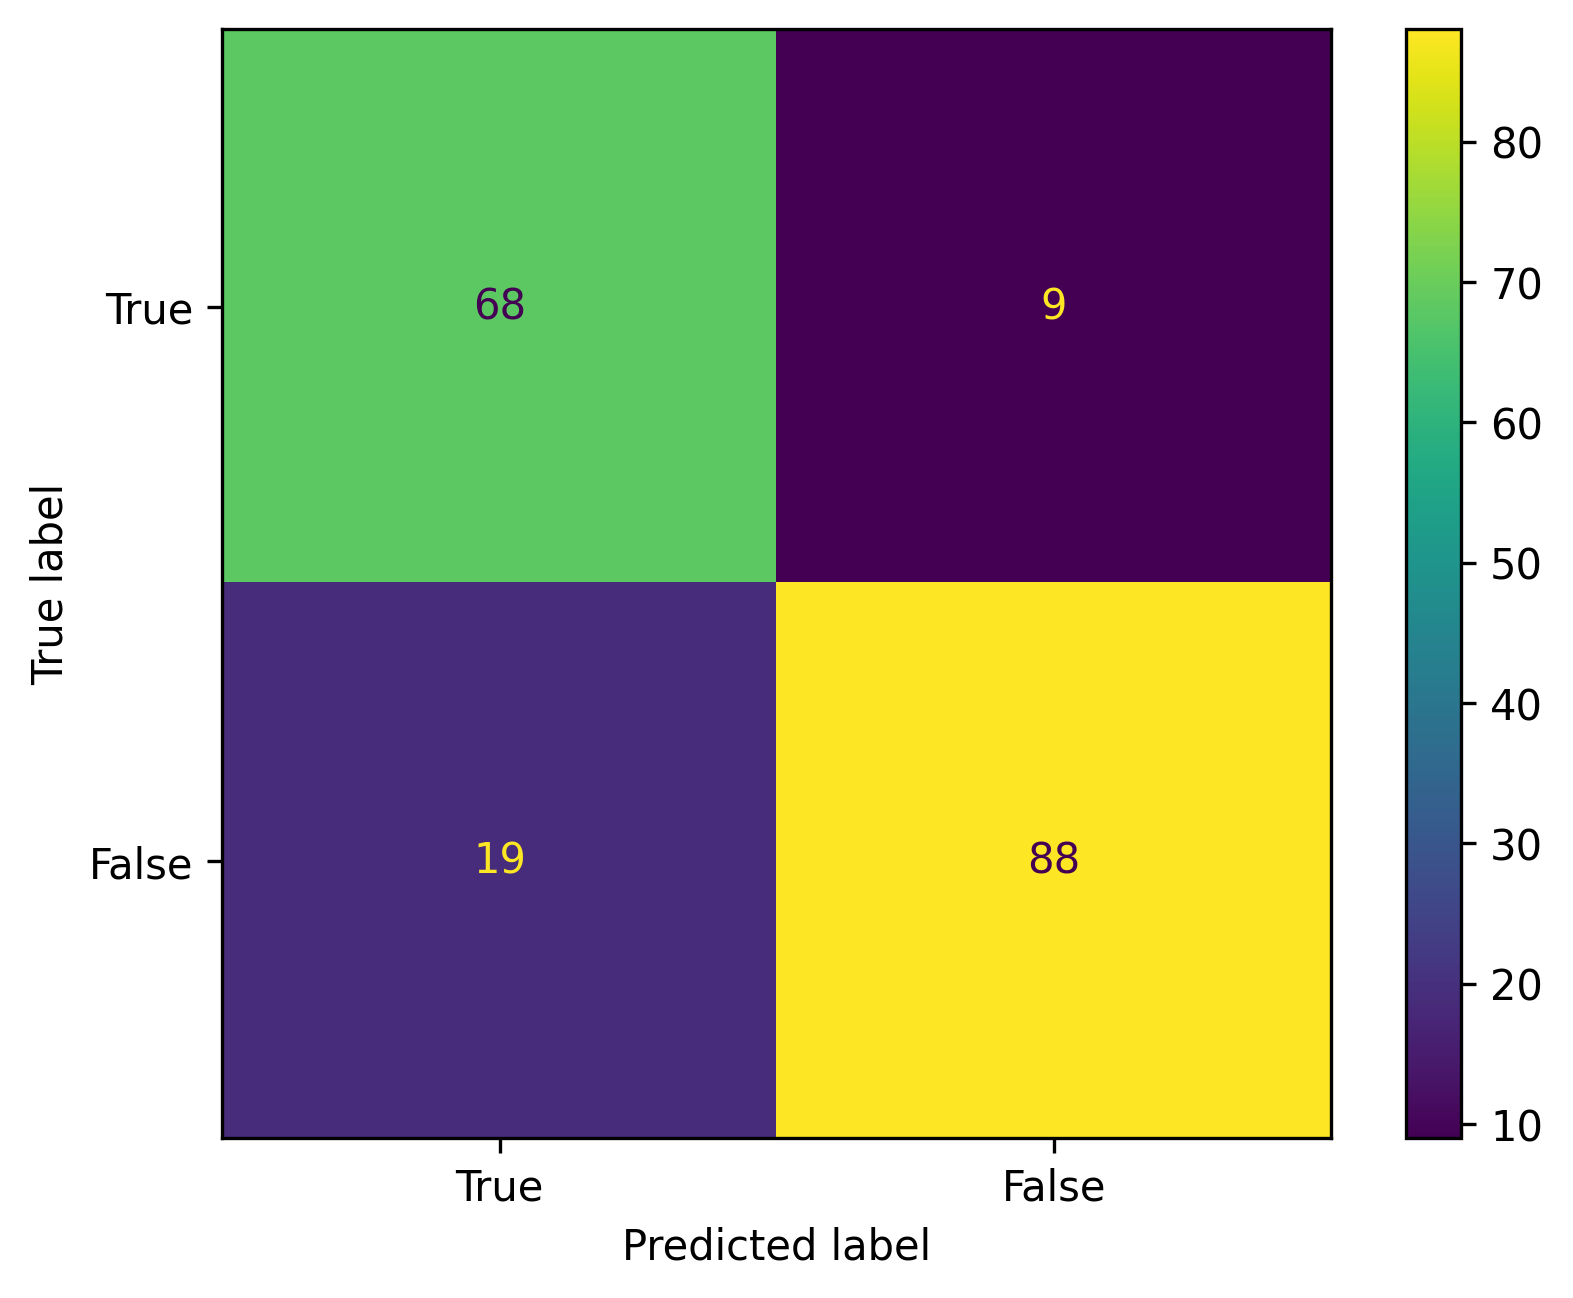

Test Measures:
Accuracy: 0.847826
Precision: 0.907216
Recall: 0.822430
F1_Score: 0.862745
Matthews correlation coefficient: 0.697136


In [27]:
accu = accuracy_score(y_test,yhat)
prec = precision_score(y_test,yhat)
rec = recall_score(y_test,yhat)
fs = f1_score(y_test,yhat)
mcc = matthews_corrcoef(y_test,yhat)
cm = confusion_matrix(y_test,yhat)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [True, False])
cm_display.plot()
plt.show()
print('Test Measures:')
print('Accuracy: %f' % accu)
print('Precision: %f' % prec)
print('Recall: %f' % rec)
print('F1_Score: %f' % fs)
print('Matthews correlation coefficient: %f' % mcc)
# print('Confusion Matrix: %f' % cm)